# Machine Learning - Insurance Claims Forecasting

## Objective
Build predictive models to forecast the number of car-insurance claims per policy period using Poisson regression and XGBoost.

## Dataset Overview
- **Target**: ClaimNb (Number of claims during exposure period)
- **Key Features**: DrivAge, VehAge, BonusMalus, VehPower, Area, Density, Region, VehBrand, VehGas
- **Important**: Exposure (time-weighted factor for normalization)

## Section 1: Imports & Setup

In [89]:
! pip install statsmodels xgboost scikit-learn matplotlib seaborn pandas numpy

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.6 MB 1.5 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.6 MB 1.5 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.6 MB 1.4 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.6 MB 1.4 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.6 MB 1.4 MB/s eta 0:00:06
   --------- ------------------------------ 2.4/9.6 MB 1.3 MB/s eta 0:00:06
   ---------- ----------------------------- 2.6/9.6 MB 1.3 MB/s eta 0:00:06
   ------------ --------------------------- 2.9/9.6 MB 1.3 MB/s eta 0:00:06
   ------------- --------------------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Youss\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance
from statsmodels.discrete.count_model import ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Section 2: Data Loading & Inspection

1. Loading and inspecting dataset

In [48]:
def load_and_inspect_data(filepath):
    df = pd.read_csv(filepath)
    print(f'Dataset shape: {df.shape}')
    print(f'\nFirst few rows:\n{df.head()}')
    print(f'\nData types:\n{df.dtypes}')
    print(f'\nBasic statistics:\n{df.describe()}')
    return df

df = load_and_inspect_data('freMTPL2freq.csv')

Dataset shape: (678013, 12)

First few rows:
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand   VehGas  Density Region  
0      B12  Regular     1217    R82  
1      B12  Regular     1217    R82  
2      B12   Diesel       54    R22  
3      B12   Diesel       76    R72  
4      B12   Diesel       76    R72  

Data types:
IDpol         float64
ClaimNb         int64
Exposure      float64
Area           object
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand       object
VehGas         object
Density         int64
Region         object

Initial thoughts: 
 1. first three quadrant of ClaimNB are null meaning the vast* majority of ppl don't file claims -> eludes to using a Zero-Inflated model like a Z-I Poisson or Z-I Negative Binomial (ZINB might produce better results because of how close the mean is to variance of claim NB)
 2. max for ClaimNb is 16 which is definitely an outlier (or a particularly unlucky/annoying customer) -> needs further investigation
 3.  On avrg we have 0.5 vehicule-years exposure policies with a little less for bottom half and almost 1 vehicule-year, at least, for top 25%. Max value is 2 vehicule-years -> expected 
 4. VehPower is categorical disguised in numerical
 5. strange Max values for VehAge and DrivAge (100) definetly outliers (can u drive when u're that old??)
 6. rest seems normal

In [49]:
def handle_missing_values(df):
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f'Missing values:\n{missing[missing > 0]}')
        missing_pct = (missing / len(df)) * 100
        print(f'\nMissing percentage:\n{missing_pct[missing_pct > 0]}')
    else:
        print('No missing values found.')
    return df

def detect_and_remove_duplicates(df):
    duplicates_total = df.duplicated().sum()
    print(f"Total duplicate rows: {duplicates_total}")
    
    if duplicates_total > 0:
        df_cleaned = df.drop_duplicates()
        print(f"Original: {df.shape} → After: {df_cleaned.shape}")
        return df_cleaned
    else:
        print("No duplicates found.")
        return df

df = handle_missing_values(df)
df = detect_and_remove_duplicates(df)

No missing values found.
Total duplicate rows: 0
No duplicates found.


Great complete and clean dataset!

Let's make an Exposure-adjusted metric for future use and analysis

In [60]:
df['Claims_Per_Year'] = df['ClaimNb'] / df['Exposure']

let's investigate the outliers

In [61]:
def identify_outliers(df, numeric_cols):
    outlier_summary = {}
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = len(outliers)
    return outlier_summary

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
outliers = identify_outliers(df, numeric_cols)
print(f'Outlier Summary: {outliers}')

Outlier Summary: {'IDpol': 0, 'ClaimNb': 34060, 'Exposure': 0, 'VehPower': 35071, 'VehAge': 3114, 'DrivAge': 1275, 'BonusMalus': 62384, 'Density': 77566, 'Claims_Per_Year': 34060}


VEHICLE AGE: 26+ years
Count: 2619 | Percentage: 0.39%

Max values:
        VehAge  ClaimNb  Exposure  BonusMalus
20638      100        0      0.60          68
23867      100        0      0.54          50
26017      100        0      0.12          72
131023     100        0      1.00          72
131057     100        0      1.00          50
131108     100        0      0.21         100
131109     100        0      0.78          90
143007     100        0      0.01          60
145428     100        0      0.17          50
156823     100        0      0.63          55

DRIVER AGE: 80+ years
Count: 8105 | Percentage: 1.20%

Max values:
        DrivAge  ClaimNb  Exposure  BonusMalus
611786      100        0      0.84          50
611787      100        0      0.15          50
650314      100        0      0.74          50
7133         99        1      1.00          50
7509         99        1      1.00          50
8350         99        1      1.00          50
8351         99        1     

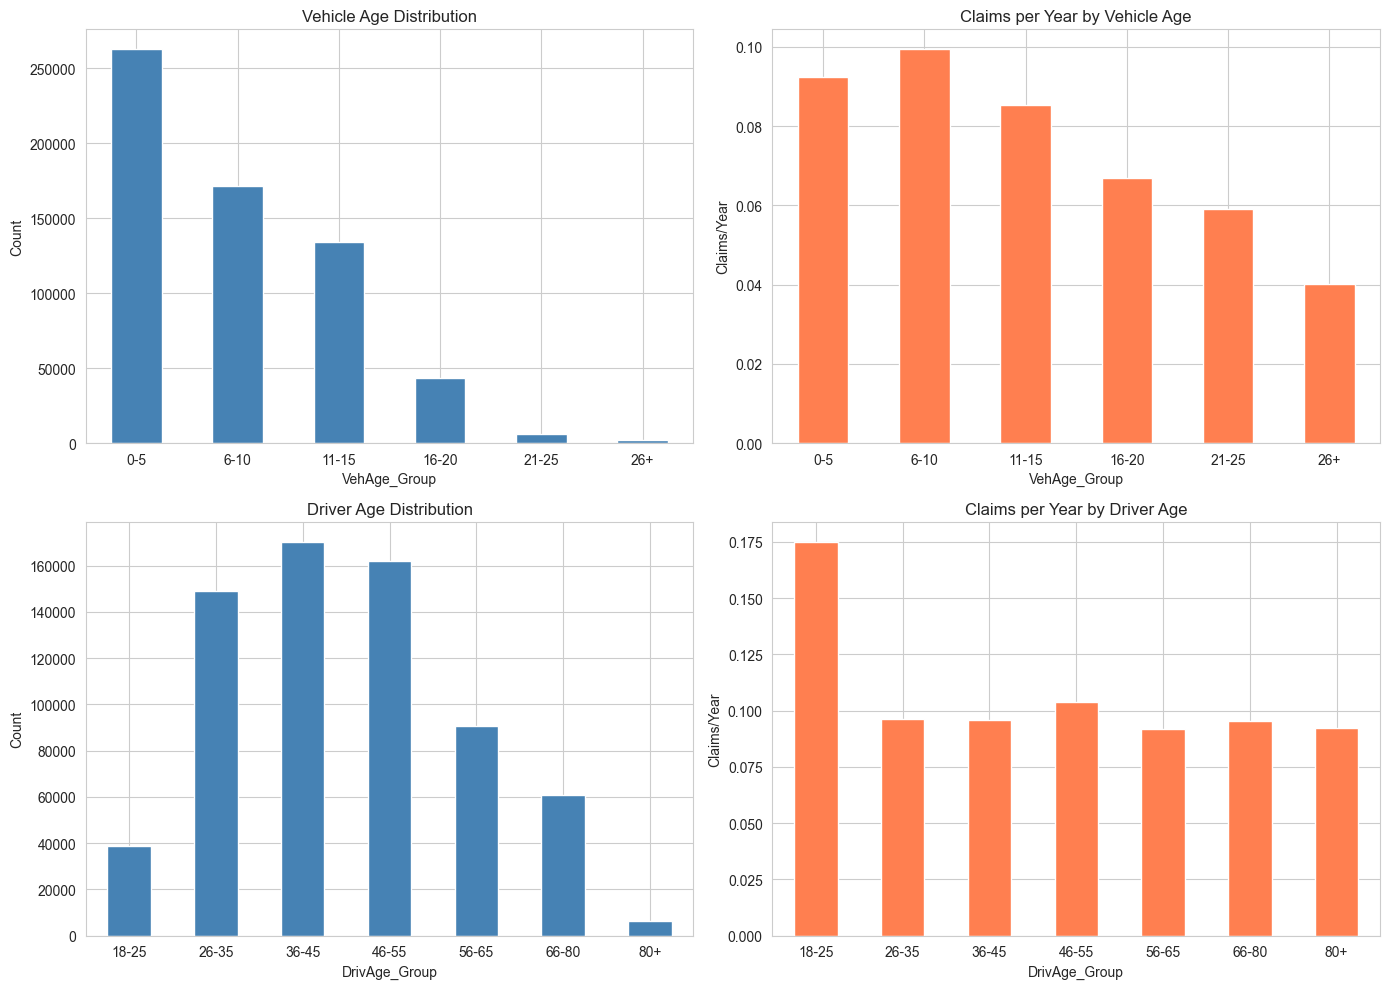

In [62]:
# VEHICLE & DRIVER AGE - QUICK ANALYSIS

print("VEHICLE AGE: 26+ years")
old_cars = df[df['VehAge'] >= 26]
print(f"Count: {len(old_cars)} | Percentage: {(len(old_cars)/len(df))*100:.2f}%")
print(f"\nMax values:")
print(old_cars.nlargest(10, 'VehAge')[['VehAge', 'ClaimNb', 'Exposure', 'BonusMalus']].to_string())

print("\n" + "="*80)
print("DRIVER AGE: 80+ years")
elderly = df[df['DrivAge'] >= 80]
print(f"Count: {len(elderly)} | Percentage: {(len(elderly)/len(df))*100:.2f}%")
print(f"\nMax values:")
print(elderly.nlargest(10, 'DrivAge')[['DrivAge', 'ClaimNb', 'Exposure', 'BonusMalus']].to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Vehicle Age Distribution
df['VehAge_Group'] = pd.cut(df['VehAge'], bins=[0, 5, 10, 15, 20, 26, 100], 
                             labels=['0-5', '6-10', '11-15', '16-20', '21-25', '26+'])
df['VehAge_Group'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Vehicle Age Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# Vehicle Age vs Claims per Year
vehicle_claims = df.groupby('VehAge_Group', observed=True).apply(
    lambda x: x['ClaimNb'].sum() / x['Exposure'].sum()
)
vehicle_claims.plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Claims per Year by Vehicle Age')
axes[0, 1].set_ylabel('Claims/Year')
axes[0, 1].tick_params(axis='x', rotation=0)

# Driver Age Distribution
df['DrivAge_Group'] = pd.cut(df['DrivAge'], bins=[0, 25, 35, 45, 55, 65, 80, 150],
                              labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66-80', '80+'])
df['DrivAge_Group'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Driver Age Distribution')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=0)

# Driver Age vs Claims per Year
driver_claims = df.groupby('DrivAge_Group', observed=True).apply(
    lambda x: x['ClaimNb'].sum() / x['Exposure'].sum()
)
driver_claims.plot(kind='bar', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Claims per Year by Driver Age')
axes[1, 1].set_ylabel('Claims/Year')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Although they seemed suspicious at first, the values of the elderly in both cars and drivers seem to fit the general data. We can explore this more in the next sectio for univariate EDA

## Section 3: Exploratory Data Analysis (EDA)

Univariate

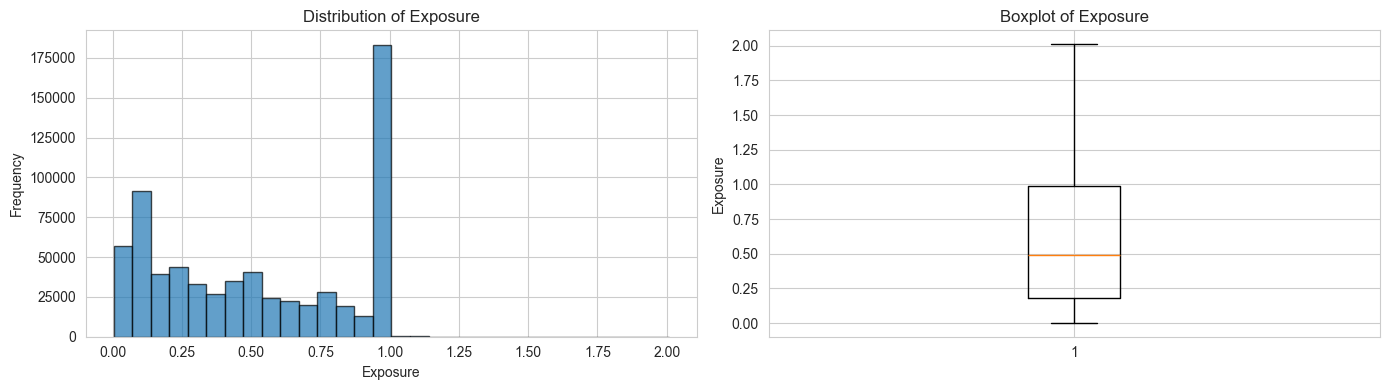

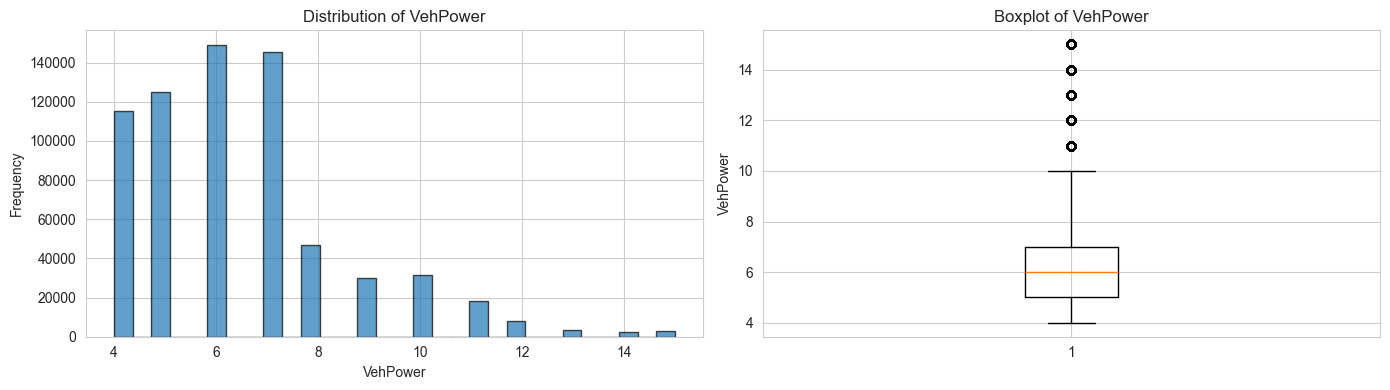

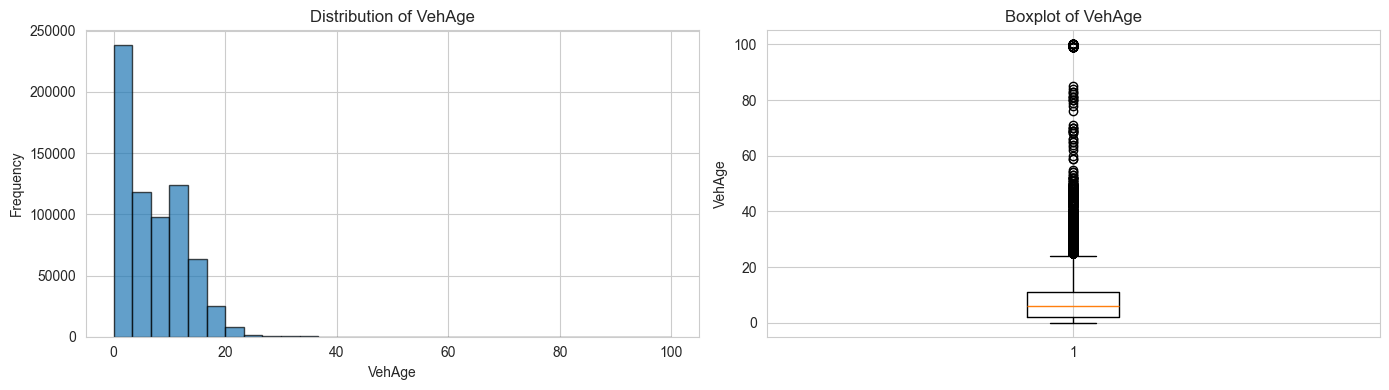

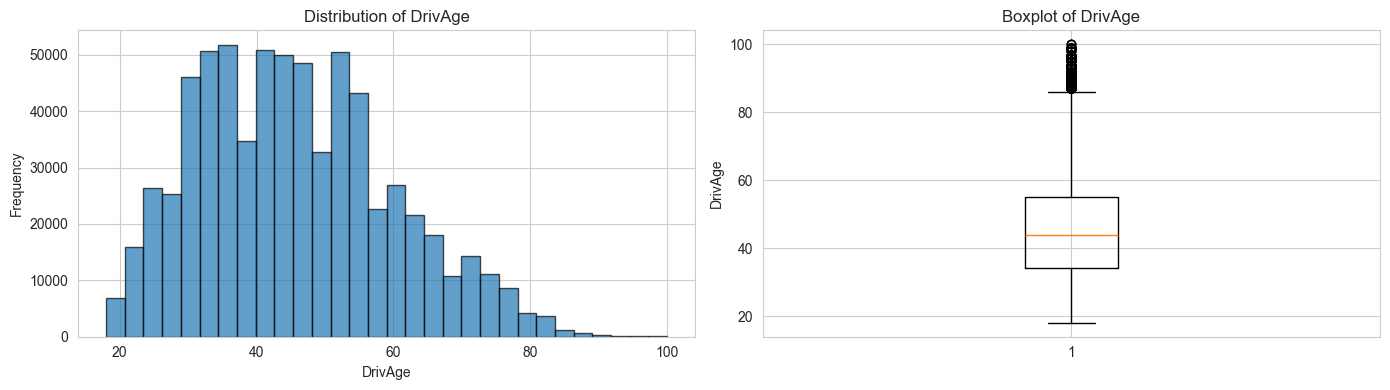

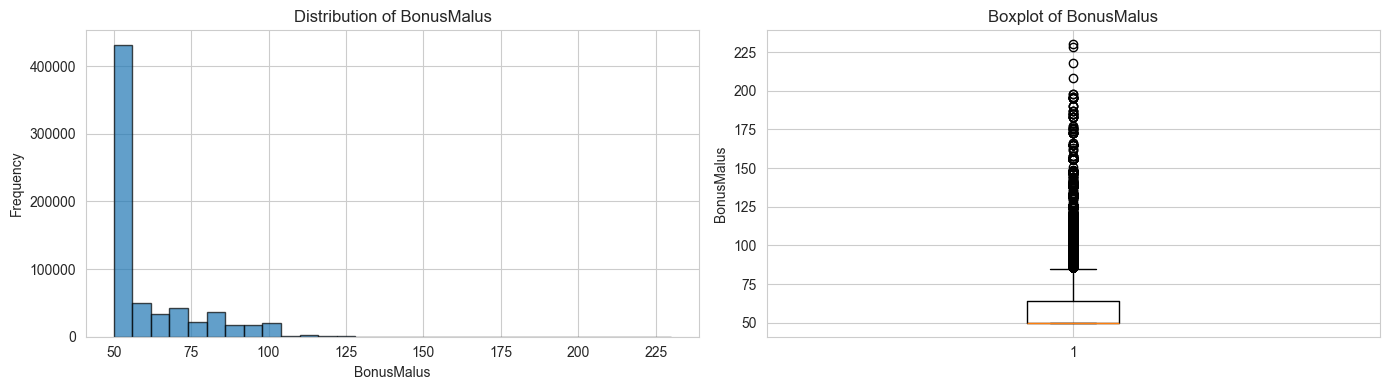

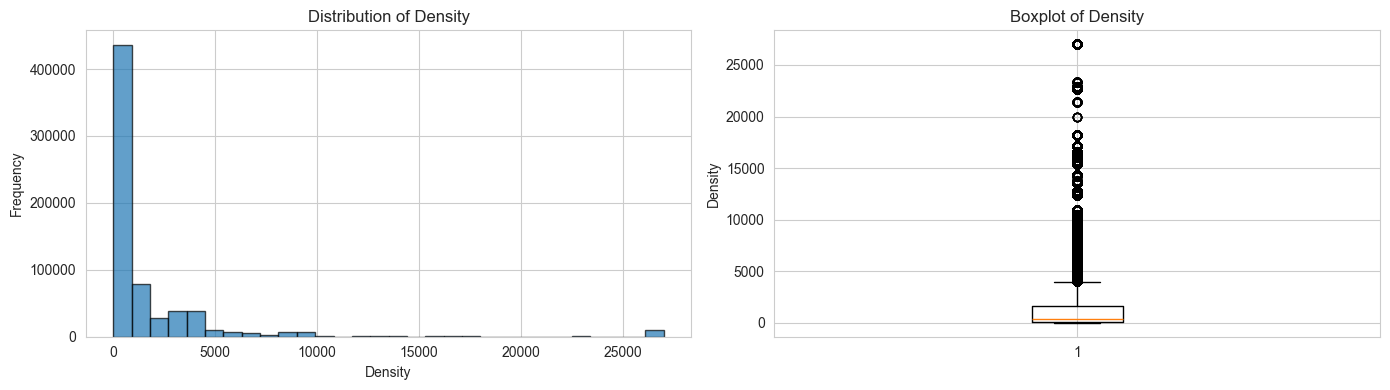

In [52]:
def eda_univariate(df, numeric_cols, target_col='ClaimNb'):
    for col in numeric_cols:
        if col == target_col:
            continue
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        axes[0].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
        axes[0].set_title(f'Distribution of {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')
        
        axes[1].boxplot(df[col])
        axes[1].set_title(f'Boxplot of {col}')
        axes[1].set_ylabel(col)
        
        plt.tight_layout()
        plt.show()

eda_univariate(df, numeric_cols[1:])

Target distribution (just to show that the vast majority dont file claims) and Feature Engineering a new feature to account for exposure (Claims per year)

UNIVARIATE EDA - CLAIMS BY CATEGORIES



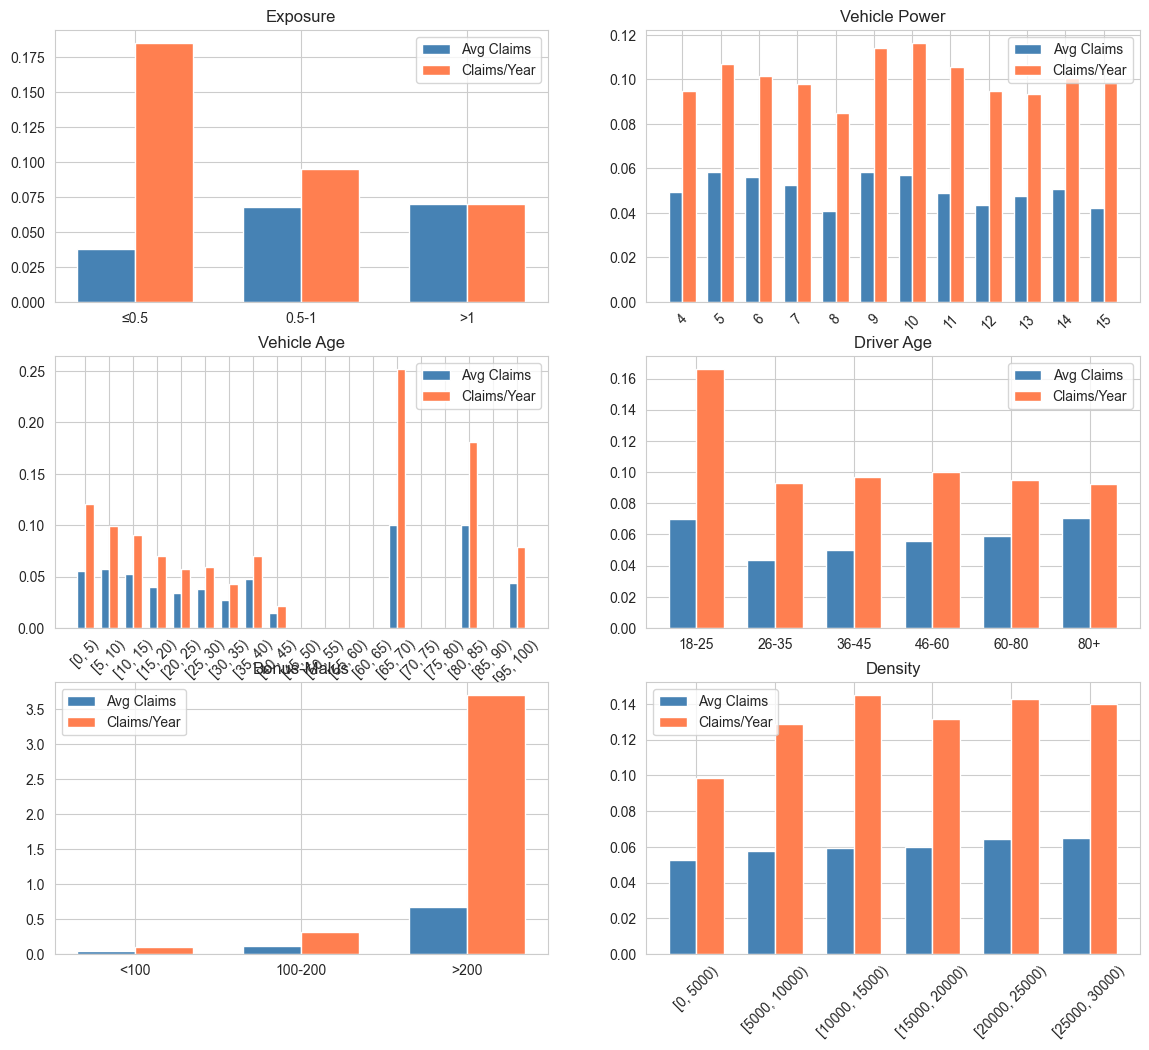

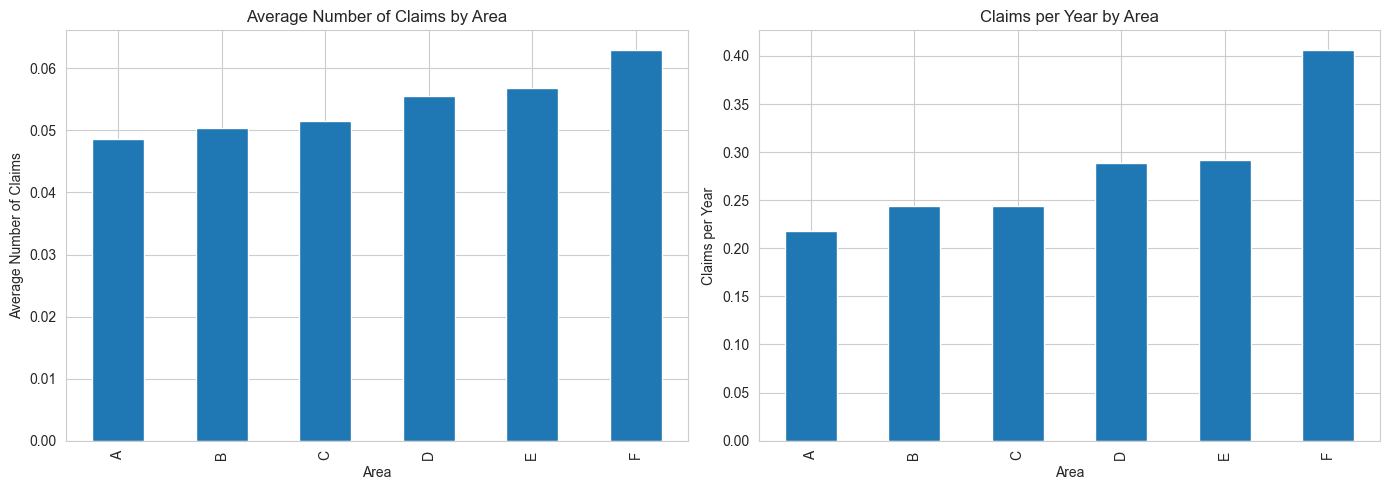

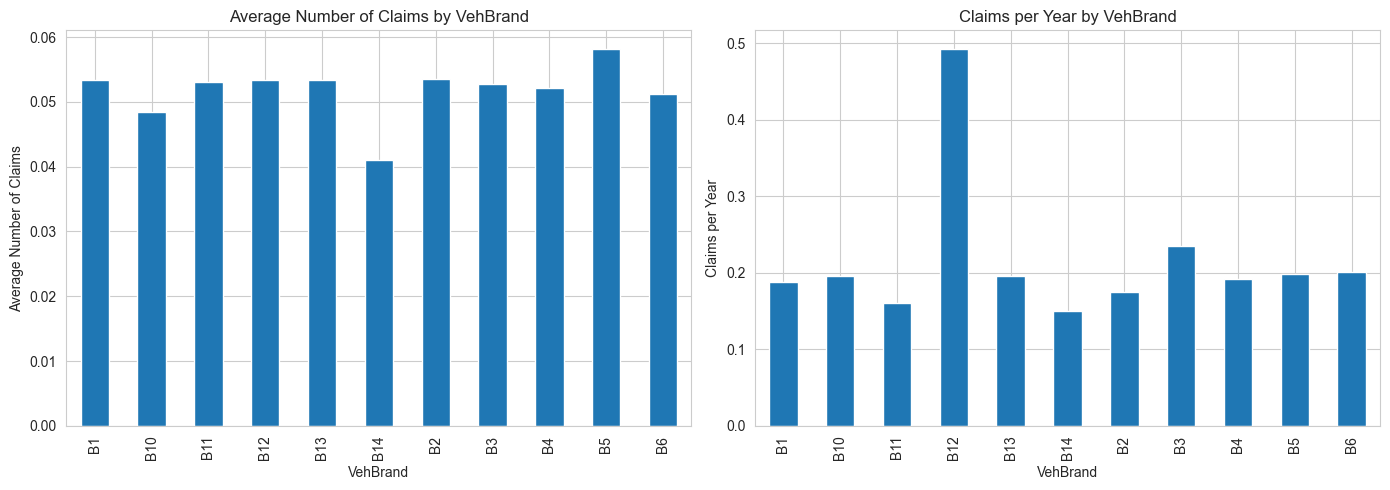

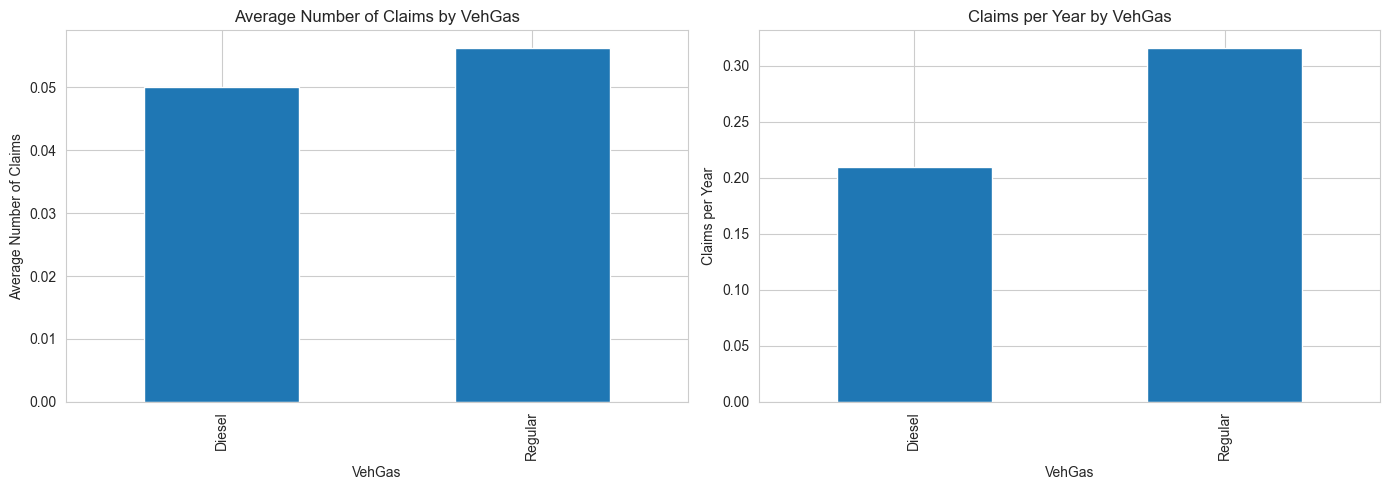

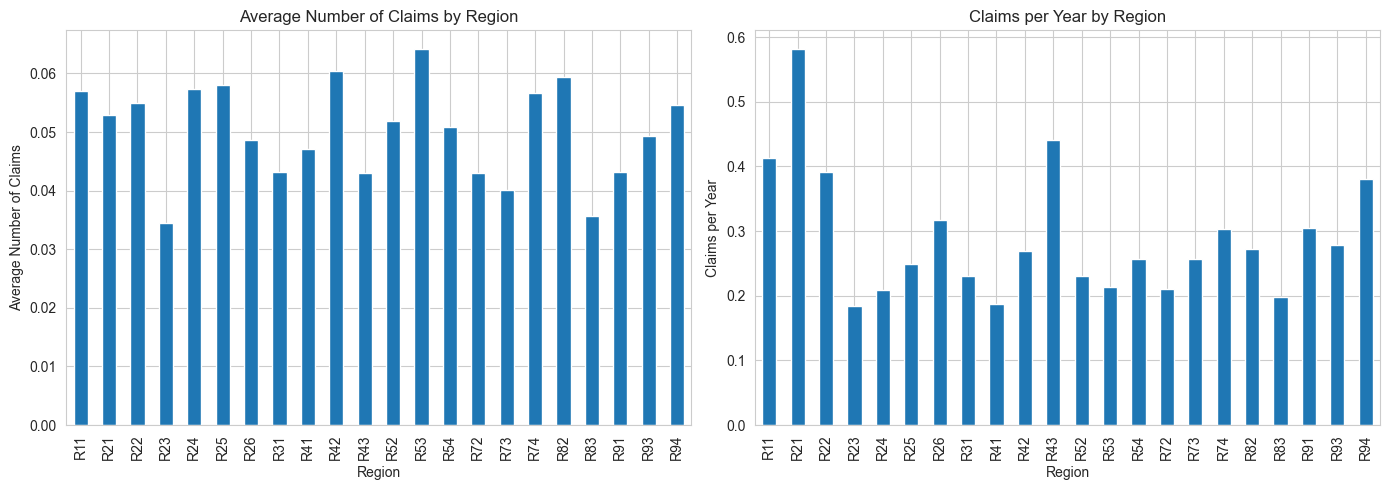

<Figure size 1200x600 with 0 Axes>

In [66]:
print("UNIVARIATE EDA - CLAIMS BY CATEGORIES\n")

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

#EXPOSURE
exp_bins = [0, 0.5, 1, df['Exposure'].max()]
exp_labels = ['≤0.5', '0.5-1', '>1']
df['Exp_Group'] = pd.cut(df['Exposure'], bins=exp_bins, labels=exp_labels, right=False)
exp_data = df.groupby('Exp_Group', observed=True).agg({'ClaimNb': 'mean', 'Exposure': 'sum'})
exp_data['Claims_Per_Year'] = df.groupby('Exp_Group', observed=True).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
x = range(len(exp_data))
width = 0.35
axes[0].bar([i - width/2 for i in x], exp_data['ClaimNb'], width, label='Avg Claims', color='steelblue')
axes[0].bar([i + width/2 for i in x], exp_data['Claims_Per_Year'], width, label='Claims/Year', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(exp_data.index)
axes[0].set_title('Exposure')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

#VEHICLE POWER
veh_power_data = df.groupby('VehPower', observed=True).agg({'ClaimNb': 'mean', 'Exposure': 'sum'})
veh_power_data['Claims_Per_Year'] = df.groupby('VehPower', observed=True).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
x = range(len(veh_power_data))
width = 0.35
axes[1].bar([i - width/2 for i in x], veh_power_data['ClaimNb'], width, label='Avg Claims', color='steelblue')
axes[1].bar([i + width/2 for i in x], veh_power_data['Claims_Per_Year'], width, label='Claims/Year', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(veh_power_data.index, rotation=45)
axes[1].set_title('Vehicle Power')
axes[1].legend()

#VEHICLE AGE (5-year bins)
veh_bins = range(0, int(df['VehAge'].max()) + 5, 5)
df['VehAge_Bin'] = pd.cut(df['VehAge'], bins=veh_bins, right=False)
veh_age_data = df.groupby('VehAge_Bin', observed=True).agg({'ClaimNb': 'mean', 'Exposure': 'sum'})
veh_age_data['Claims_Per_Year'] = df.groupby('VehAge_Bin', observed=True).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
x = range(len(veh_age_data))
width = 0.35
axes[2].bar([i - width/2 for i in x], veh_age_data['ClaimNb'], width, label='Avg Claims', color='steelblue')
axes[2].bar([i + width/2 for i in x], veh_age_data['Claims_Per_Year'], width, label='Claims/Year', color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels([str(cat) for cat in veh_age_data.index], rotation=45)
axes[2].set_title('Vehicle Age')
axes[2].legend()

# DRIVER AGE
driv_bins = [0, 26, 36, 46, 60, 80, 150]
driv_labels = ['18-25', '26-35', '36-45', '46-60', '60-80', '80+']
df['DrivAge_Bin'] = pd.cut(df['DrivAge'], bins=driv_bins, labels=driv_labels)
driv_age_data = df.groupby('DrivAge_Bin', observed=True).agg({'ClaimNb': 'mean', 'Exposure': 'sum'})
driv_age_data['Claims_Per_Year'] = df.groupby('DrivAge_Bin', observed=True).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
x = range(len(driv_age_data))
width = 0.35
axes[3].bar([i - width/2 for i in x], driv_age_data['ClaimNb'], width, label='Avg Claims', color='steelblue')
axes[3].bar([i + width/2 for i in x], driv_age_data['Claims_Per_Year'], width, label='Claims/Year', color='coral')
axes[3].set_xticks(x)
axes[3].set_xticklabels(driv_age_data.index)
axes[3].set_title('Driver Age')
axes[3].legend()
axes[3].tick_params(axis='x', rotation=0)

# BONUS-MALUS
bm_bins = [0, 100, 200, df['BonusMalus'].max()]
bm_labels = ['<100', '100-200', '>200']
df['BM_Bin'] = pd.cut(df['BonusMalus'], bins=bm_bins, labels=bm_labels, right=False)
bm_data = df.groupby('BM_Bin', observed=True).agg({'ClaimNb': 'mean', 'Exposure': 'sum'})
bm_data['Claims_Per_Year'] = df.groupby('BM_Bin', observed=True).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
x = range(len(bm_data))
width = 0.35
axes[4].bar([i - width/2 for i in x], bm_data['ClaimNb'], width, label='Avg Claims', color='steelblue')
axes[4].bar([i + width/2 for i in x], bm_data['Claims_Per_Year'], width, label='Claims/Year', color='coral')
axes[4].set_xticks(x)
axes[4].set_xticklabels(bm_data.index)
axes[4].set_title('Bonus-Malus')
axes[4].legend()
axes[4].tick_params(axis='x', rotation=0)

# DENSITY (5000-step bins)
dens_bins = range(0, int(df['Density'].max()) + 5000, 5000)
df['Dens_Bin'] = pd.cut(df['Density'], bins=dens_bins, right=False)
dens_data = df.groupby('Dens_Bin', observed=True).agg({'ClaimNb': 'mean', 'Exposure': 'sum'})
dens_data['Claims_Per_Year'] = df.groupby('Dens_Bin', observed=True).apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
x = range(len(dens_data))
width = 0.35
axes[5].bar([i - width/2 for i in x], dens_data['ClaimNb'], width, label='Avg Claims', color='steelblue')
axes[5].bar([i + width/2 for i in x], dens_data['Claims_Per_Year'], width, label='Claims/Year', color='coral')
axes[5].set_xticks(x)
axes[5].set_xticklabels([str(cat) for cat in dens_data.index], rotation=45)
axes[5].set_title('Density')
axes[5].legend()

def eda_categorical(df, categorical_cols, target_col='ClaimNb', exposure_col='Exposure'):
    for col in categorical_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        claim_by_cat = df.groupby(col)[target_col].mean()
        claim_by_cat.plot(kind='bar', ax=axes[0])
        axes[0].set_title(f'Average Number of Claims by {col}')
        axes[0].set_ylabel('Average Number of Claims')
        axes[0].set_xlabel(col)
        
        exposure_adj = df.groupby(col).apply(lambda x: (x[target_col] / x[exposure_col]).mean())
        exposure_adj.plot(kind='bar', ax=axes[1])
        axes[1].set_title(f'Claims per Year by {col}')
        axes[1].set_ylabel('Claims per Year')
        axes[1].set_xlabel(col)
        
        plt.tight_layout()
        plt.show()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
eda_categorical(df, categorical_cols)

plt.tight_layout()
plt.show()

Insights:
1. there are chunks of vehicule ages missing. Curious, not sure to attribute it to data quality or explain it by vintage car collectors 
2. Nothing really stands out except brand B12 and region R21 having an abnormal claims per year but a normal claims avrg -> this means they have shorter exposure

## Section 4: Visualizations & Feature Interactions

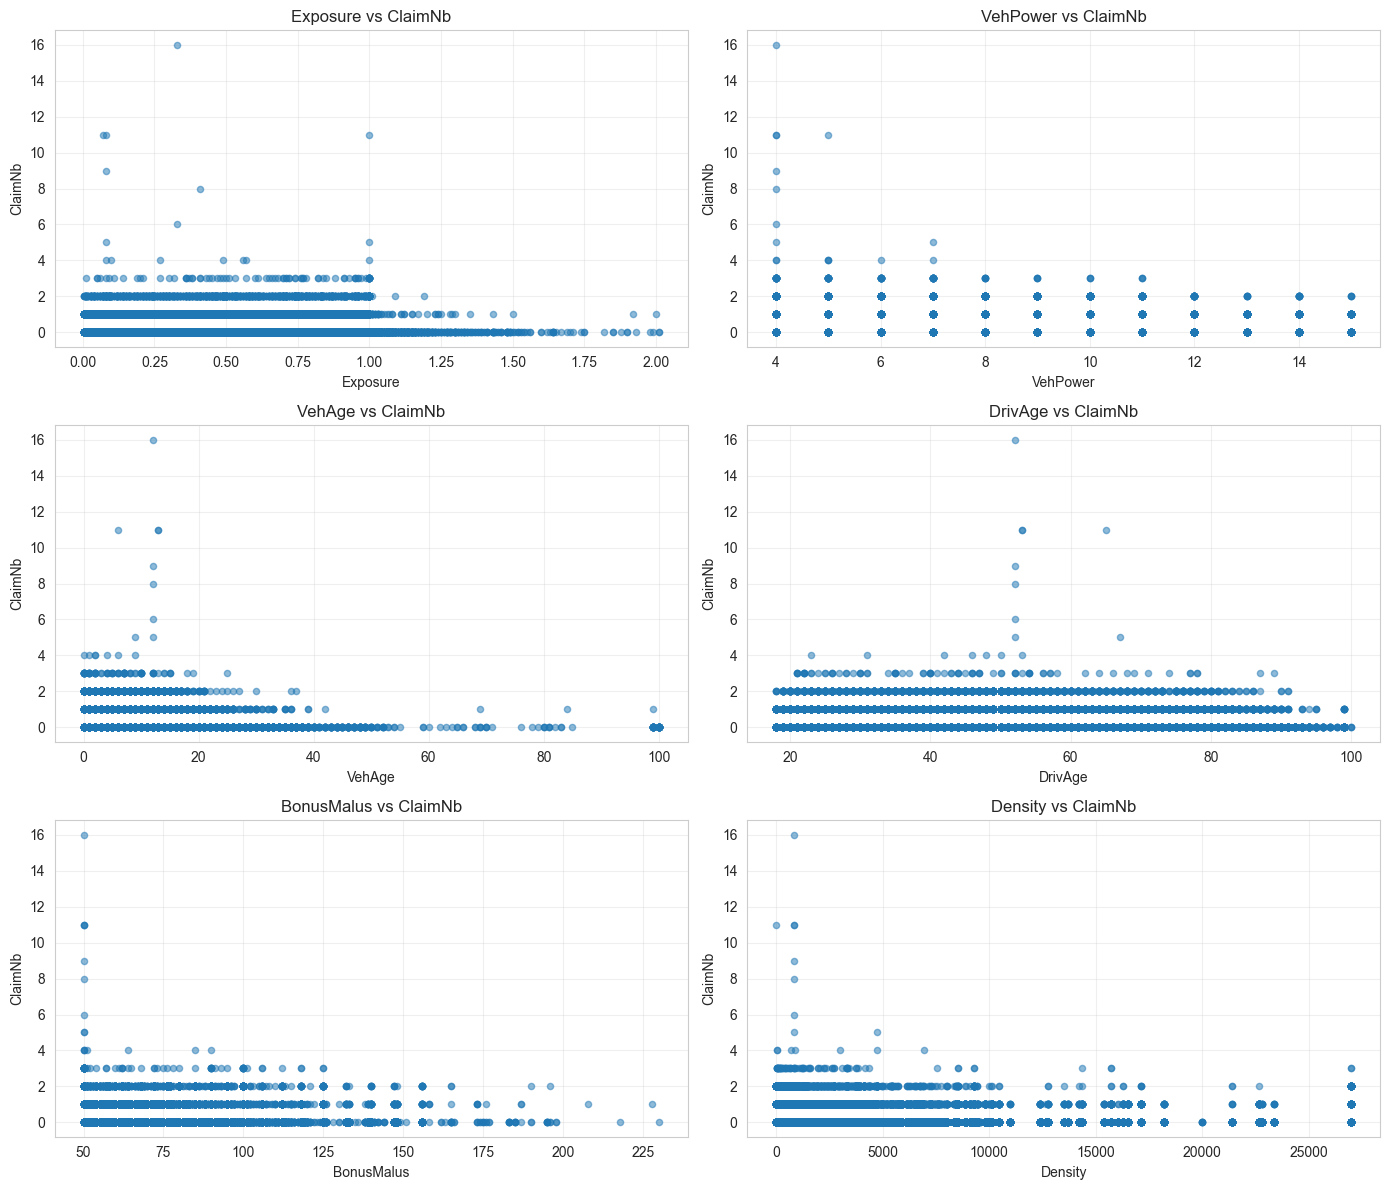

In [68]:
def plot_interactions(df, target_col='ClaimNb'):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    numeric_cols.remove(target_col)
    if 'IDpol' in numeric_cols:
        numeric_cols.remove('IDpol')
    if 'Claims_Per_Year' in numeric_cols:
        numeric_cols.remove('Claims_Per_Year')
    
    n_features = len(numeric_cols)
    n_cols = 2
    n_rows = (n_features + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols):
        axes[idx].scatter(df[col], df[target_col], alpha=0.5, s=20)
        axes[idx].set_title(f'{col} vs {target_col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel(target_col)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

plot_interactions(df)

2-claim (or higher) events chance
1. more common for less than 1 year exposure, practically never for more than 1 year
2. more claims for lower power vehicules but 2-claim events are as commom across the board
3. happen across age demographic uniformally
4. happens less and less as Vehicule Age increases (for cars between 0 and 40 years of age) with 20 years beign a cut-oof point and never for "vintage" cars
5. more common and intense for lower Malus, decreases as bonus increases (above 125)
6. most data point have lower density which explains the behavior. The trend is not to be determined yet

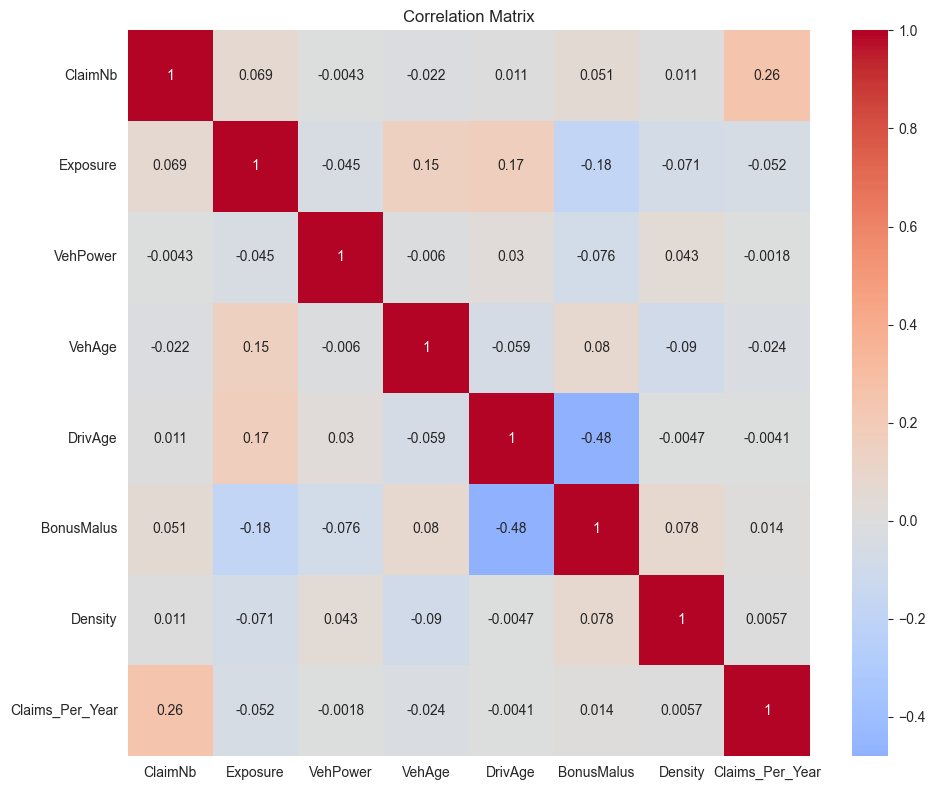

In [69]:
def plot_correlation_matrix(df, numeric_cols):
    correlation_matrix = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(df, numeric_cols[1:])

Key Insights:
1. ClaimNb (0.069) vs Claims_Per_Year (0.26): The exposure-adjusted metric is almost 4x more correlated with itself, confirming we need to account for exposure
2. Exposure correlations: Exposure has weak correlations across the board, meaning longer policies aren't systematically riskier
3. No multicollinearity: No feature pairs are highly correlated (>0.5), so we can keep all of them

## Section 5: Feature Engineering & Preprocessing

In [76]:
def preprocess_data(df, target_col='ClaimNb', exposure_col='Exposure'):
    df_processed = df.copy()
    
    categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
    numeric_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
    numeric_cols.remove(target_col)
    # if exposure_col in numeric_cols:
    #     numeric_cols.remove(exposure_col)
    
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])
        label_encoders[col] = le
    deleted_cols = ['VehAge_Group', 'DrivAge_Group', 'Claims_Per_Year', 'Exp_Group', 'VehAge_Bin', 'DrivAge_Bin', 'BM_Bin', 'Dens_Bin']
    X = df_processed.drop(columns=[target_col] + deleted_cols)
    y = df_processed[target_col]
    sample_weights = df_processed[exposure_col]
    
    return X, y, sample_weights, numeric_cols, categorical_cols

X, y, sample_weights, numeric_cols, categorical_cols = preprocess_data(df)
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

Features shape: (678013, 11) ['IDpol', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']
Target shape: (678013,)


In [78]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weights, test_size=0.2, random_state=42
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (542410, 11)
Test set: (135603, 11)


# Section 6: Model Selction 
## Model 1.A - Poisson Regression

In [79]:
def train_poisson_model(X_train, y_train, sample_weights_train):
    poisson_model = PoissonRegressor(alpha=0.0001, max_iter=1000)
    poisson_model.fit(X_train, y_train, sample_weight=sample_weights_train)
    return poisson_model

poisson_model = train_poisson_model(X_train, y_train, w_train)
print('Poisson model trained successfully')

Poisson model trained successfully


In [ ]:
def evaluate_poisson(model, X_test, y_test, sample_weights_test):
    y_pred = model.predict(X_test)
    # y_pred = np.round(model.predict(X_test))
    mae = mean_absolute_error(y_test, y_pred, sample_weight=sample_weights_test)
    mse = mean_squared_error(y_test, y_pred, sample_weight=sample_weights_test)
    rmse = np.sqrt(mse)
    poisson_dev = mean_poisson_deviance(y_test, y_pred, sample_weight=sample_weights_test)
    
    print(f'Poisson Model Results:')
    print(f'  MAE: {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  Mean Poisson Deviance: {poisson_dev:.4f}')
    
    # return y_pred, {'mae': mae, 'rmse': rmse}
    return y_pred, {'mae': mae, 'rmse': rmse, 'poisson_deviance': poisson_dev}

poisson_pred, poisson_metrics = evaluate_poisson(poisson_model, X_test, y_test, w_test)

Poisson Model Results:
  MAE: 0.1198
  RMSE: 0.2576
  Mean Poisson Deviance: 0.3450


## Model 1.B - Zero-Inflated Poisson

In [307]:
def train_zip_model(X_train, y_train, sample_weights_train):
    zip_model = ZeroInflatedPoisson(y_train, X_train, exog_infl=X_train)
    zip_model = zip_model.fit(disp=False)
    return zip_model

zip_model = train_zip_model(X_train, y_train, w_train)
print('Zero-Inflated Poisson model trained successfully')

def evaluate_zip(model, X_test, y_test, sample_weights_test):
    y_pred = model.predict(exog=X_test, exog_infl=X_test)
    y_pred = np.maximum(y_pred, 0.001)
    mae = mean_absolute_error(y_test, y_pred, sample_weight=sample_weights_test)
    mse = mean_squared_error(y_test, y_pred, sample_weight=sample_weights_test)
    rmse = np.sqrt(mse)
    poisson_dev = mean_poisson_deviance(y_test, y_pred, sample_weight=sample_weights_test)

    print(f'Zero-Inflated Poisson Model Results:')
    print(f'  MAE: {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  Mean Poisson Deviance: {poisson_dev:.4f}')
    return y_pred, {'mae': mae, 'rmse': rmse, 'poisson_dev': poisson_dev}

zip_pred, zip_metrics = evaluate_zip(zip_model, X_test, y_test, w_test)

Zero-Inflated Poisson model trained successfully
Zero-Inflated Poisson Model Results:
  MAE: 0.0659
  RMSE: 0.2689
  Mean Poisson Deviance: 0.7801


## Model 2.A - Negative Binomial

In [186]:

def train_nb_model(X_train, y_train, sample_weights_train):
    nb_model = sm.NegativeBinomial(y_train, X_train)
    nb_model = nb_model.fit(disp=False)
    return nb_model

nb_model = train_nb_model(X_train, y_train, w_train)
print('Negative Binomial model trained successfully')

def evaluate_nb(model, X_test, y_test, sample_weights_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred, sample_weight=sample_weights_test)
    mse = mean_squared_error(y_test, y_pred, sample_weight=sample_weights_test)
    rmse = np.sqrt(mse)
    poisson_dev = mean_poisson_deviance(y_test, y_pred, sample_weight=sample_weights_test)
    
    print(f'Negative Binomial Model Results:')
    print(f'  MAE: {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  Mean Poisson Deviance: {poisson_dev:.4f}')
    
    return y_pred, {'mae': mae, 'rmse': rmse, 'poisson_deviance': poisson_dev}

nb_pred, nb_metrics = evaluate_nb(nb_model, X_test, y_test, w_test)


Negative Binomial model trained successfully
Negative Binomial Model Results:
  MAE: 0.1184
  RMSE: 0.2602
  Mean Poisson Deviance: 0.3637


## Model 2.B - Zero-Inflated Negative Binomial

In [318]:

def train_zinb_model(X_train, y_train, sample_weights_train):
    zinb_model = ZeroInflatedNegativeBinomialP(y_train, X_train)
    zinb_model = zinb_model.fit(disp=False)
    return zinb_model

zinb_model = train_zinb_model(X_train, y_train, w_train)
print('Zero-Inflated Negative Binomial model trained successfully')
def evaluate_zinb(model, X_test, y_test, sample_weights_test):
    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 0.001, np.inf)
    y_pred = np.nan_to_num(y_pred, nan=0.001, posinf=1e6, neginf=0.001)
    
    mae = mean_absolute_error(y_test, y_pred, sample_weight=sample_weights_test)
    mse = mean_squared_error(y_test, y_pred, sample_weight=sample_weights_test)
    rmse = np.sqrt(mse)
    
    print(f'Zero-Inflated Negative Binomial Model Results:')
    print(f'  MAE: {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    
    return y_pred, {'mae': mae, 'rmse': rmse}

zinb_pred, zinb_metrics = evaluate_zinb(zinb_model, X_test, y_test, w_test)

Zero-Inflated Negative Binomial model trained successfully
Zero-Inflated Negative Binomial Model Results:
  MAE: 999999.9350
  RMSE: 999999.9350


*I was absolutely wrong this model is not the one we are looking for *

## Model 4 - XGBoost

In [130]:
def train_xgboost_model(X_train, y_train, sample_weights_train):
    xgb_model = xgb.XGBRegressor(
        objective='count:poisson',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)
    return xgb_model

xgb_model = train_xgboost_model(X_train, y_train, w_train)
print('XGBoost model trained successfully')

XGBoost model trained successfully


In [ ]:
def evaluate_xgboost(model, X_test, y_test, sample_weights_test):
    # y_pred = model.predict(X_test)
    y_pred = np.round(model.predict(X_test))
    mae = mean_absolute_error(y_test, y_pred, sample_weight=sample_weights_test)
    mse = mean_squared_error(y_test, y_pred, sample_weight=sample_weights_test)
    rmse = np.sqrt(mse)
    poisson_dev = mean_poisson_deviance(y_test, y_pred, sample_weight=sample_weights_test)
    
    print(f'XGBoost Model Results:')
    print(f'  MAE: {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  Mean Poisson Deviance: {poisson_dev:.4f}')
    
    return y_pred, {'mae': mae, 'rmse': rmse, 'poisson_deviance': poisson_dev}

xgb_pred, xgb_metrics = evaluate_xgboost(xgb_model, X_test, y_test, w_test)

XGBoost Model Results:
  MAE: 0.1002
  RMSE: 0.2331
  Mean Poisson Deviance: 0.2910


## Visualisation for models 

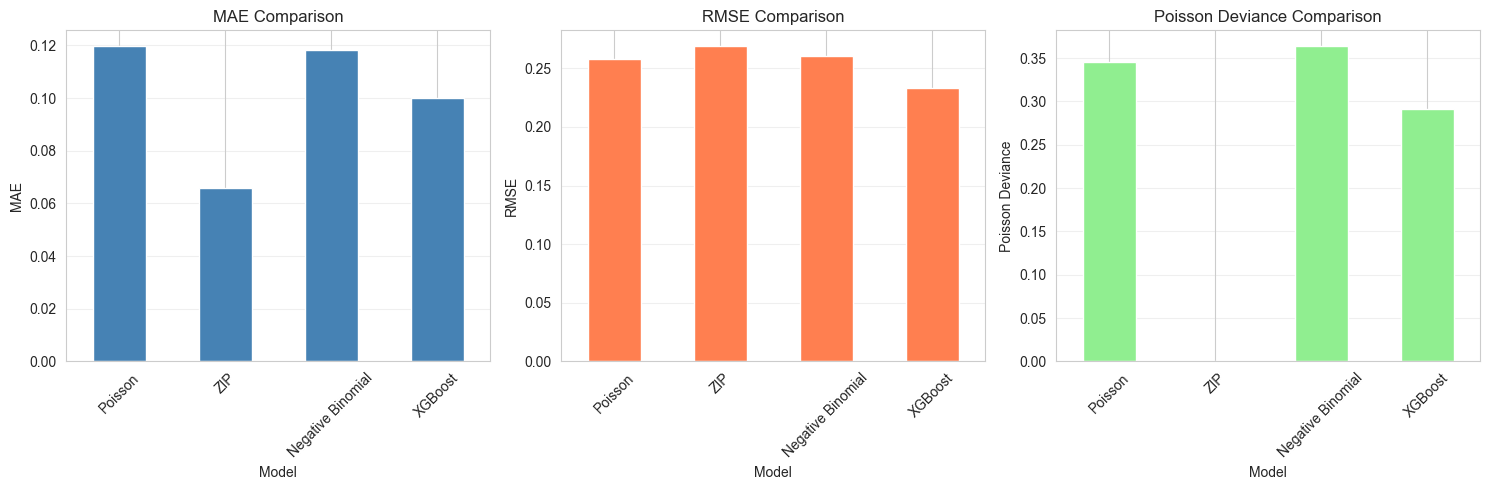

            Model      MAE     RMSE  Poisson Deviance
          Poisson 0.119755 0.257566          0.345035
              ZIP 0.065897 0.268852               NaN
Negative Binomial 0.118398 0.260153          0.363744
          XGBoost 0.100191 0.233146          0.290993


In [317]:
comparison_df = pd.DataFrame({
    'Model': ['Poisson', 'ZIP', 'Negative Binomial', 'XGBoost'],
    'MAE': [poisson_metrics['mae'], zip_metrics['mae'], nb_metrics['mae'], xgb_metrics['mae']],
    'RMSE': [poisson_metrics['rmse'], zip_metrics['rmse'], nb_metrics['rmse'], xgb_metrics['rmse']],
    'Poisson Deviance': [poisson_metrics['poisson_deviance'], zip_metrics.get('poisson_deviance', np.nan), nb_metrics.get('poisson_deviance', np.nan), xgb_metrics.get('poisson_deviance', np.nan)]
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

comparison_df.set_index('Model')['MAE'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

comparison_df.set_index('Model')['RMSE'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

comparison_df.set_index('Model')['Poisson Deviance'].plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Poisson Deviance Comparison')
axes[2].set_ylabel('Poisson Deviance')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(comparison_df.to_string(index=False))

the MAE of the ZIP is nearly half the other models' while the RMSE is very close. Although, its Mean Poissson Deviance is the highest, it can prove valuable to explore/tune it further. This makes me want to chose it (linear model) and XGBoost (second best results and tree-based) for further refinement.

## Section 8: Cross-Validation Analysis

In [156]:
def cross_validation_analysis(X_train, y_train, sample_weights_train):
    xgb_model = xgb.XGBRegressor(objective='count:poisson', n_estimators=100, random_state=42, verbosity=0)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    zip_mae = []
    zip_rmse = []
    zip_poisson_dev = []
    xgb_mae = []
    xgb_rmse = []
    xgb_poisson_dev = []
    
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        w_tr, w_val = sample_weights_train.iloc[train_idx], sample_weights_train.iloc[val_idx]
        
        zip_model = ZeroInflatedPoisson(y_tr, X_tr, exog_infl=X_tr)
        zip_model = zip_model.fit(disp=False)
        zip_pred = np.maximum(zip_model.predict(exog=X_val, exog_infl=X_val), 0.001)
        zip_mae.append(mean_absolute_error(y_val.values, zip_pred, sample_weight=w_val.values))
        zip_rmse.append(np.sqrt(mean_squared_error(y_val.values, zip_pred, sample_weight=w_val.values)))
        zip_poisson_dev.append(mean_poisson_deviance(y_val.values, zip_pred, sample_weight=w_val.values))
        
        xgb_model.fit(X_tr, y_tr, sample_weight=w_tr)
        xgb_pred = xgb_model.predict(X_val)
        xgb_mae.append(mean_absolute_error(y_val, xgb_pred, sample_weight=w_val))
        xgb_rmse.append(np.sqrt(mean_squared_error(y_val, xgb_pred, sample_weight=w_val)))
        xgb_poisson_dev.append(mean_poisson_deviance(y_val, xgb_pred, sample_weight=w_val))
    
    print(f'ZIP CV MAE: {np.mean(zip_mae):.4f} (+/- {np.std(zip_mae):.4f})')
    print(f'ZIP CV RMSE: {np.mean(zip_rmse):.4f} (+/- {np.std(zip_rmse):.4f})')
    print(f'ZIP CV Poisson Deviance: {np.mean(zip_poisson_dev):.4f} (+/- {np.std(zip_poisson_dev):.4f})')
    print(f'\nXGBoost CV MAE: {np.mean(xgb_mae):.4f} (+/- {np.std(xgb_mae):.4f})')
    print(f'XGBoost CV RMSE: {np.mean(xgb_rmse):.4f} (+/- {np.std(xgb_rmse):.4f})')
    print(f'XGBoost CV Poisson Deviance: {np.mean(xgb_poisson_dev):.4f} (+/- {np.std(xgb_poisson_dev):.4f})')
    
    return {'zip_mae': zip_mae, 'zip_rmse': zip_rmse, 'zip_poisson_dev': zip_poisson_dev,
            'xgb_mae': xgb_mae, 'xgb_rmse': xgb_rmse, 'xgb_poisson_dev': xgb_poisson_dev}

cv_results = cross_validation_analysis(X_train, y_train, w_train)

ZIP CV MAE: 0.0654 (+/- 0.0012)
ZIP CV RMSE: 0.2698 (+/- 0.0043)
ZIP CV Poisson Deviance: 0.7753 (+/- 0.0155)

XGBoost CV MAE: 0.0935 (+/- 0.0009)
XGBoost CV RMSE: 0.2309 (+/- 0.0039)
XGBoost CV Poisson Deviance: 0.2805 (+/- 0.0042)


## Section 9: Hyperparameter Tuning

## For XGB (grid search)

In [84]:
def hyperparameter_tuning_xgboost(X_train, y_train, sample_weights_train):
    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [50, 100, 150],
        'subsample': [0.7, 0.8, 0.9]
    }
    
    xgb_base = xgb.XGBRegressor(objective='count:poisson', random_state=42, verbosity=0)
    
    grid_search = GridSearchCV(
        xgb_base,
        param_grid,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train, sample_weight=sample_weights_train)
    
    print(f'Best parameters: {grid_search.best_params_}')
    print(f'Best CV score: {grid_search.best_score_:.4f}')
    
    return grid_search.best_estimator_

tuned_xgb = hyperparameter_tuning_xgboost(X_train, y_train, w_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.9}
Best CV score: -0.0733


In [124]:
tuned_xgb_pred, tuned_metrics = evaluate_xgboost(tuned_xgb, X_test, y_test, w_test)

XGBoost Model Results:
  MAE: 0.0942
  RMSE: 0.2321
  Mean Poisson Deviance: 0.2853


## For ZIP (random search)

In [157]:
def hyperparameter_tuning_zip_random(X_train, y_train, sample_weights_train):
    param_grid = {
        'maxiter': [50, 100, 150, 200, 250, 300, 400],
        'inflation_const': [True, False]
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    best_score = float('inf')
    best_params = None
    results = []
    
    for _ in range(10):
        maxiter = np.random.choice(param_grid['maxiter'])
        inflation_const = np.random.choice(param_grid['inflation_const'])
        
        scores = []
        
        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            w_tr, w_val = sample_weights_train.iloc[train_idx], sample_weights_train.iloc[val_idx]
            
            exog_infl = X_tr if not inflation_const else None
            exog_infl_val = X_val if not inflation_const else None
            
            zip_model = ZeroInflatedPoisson(y_tr, X_tr, exog_infl=exog_infl)
            zip_model = zip_model.fit(disp=False, maxiter=maxiter)
            zip_pred = np.maximum(zip_model.predict(exog=X_val, exog_infl=exog_infl_val), 0.001)
            mae = mean_absolute_error(y_val.values, zip_pred, sample_weight=w_val.values)
            scores.append(mae)
        
        mean_score = np.mean(scores)
        results.append({'maxiter': maxiter, 'inflation_const': inflation_const, 'score': mean_score})
        
        if mean_score < best_score:
            best_score = mean_score
            best_params = {'maxiter': maxiter, 'inflation_const': inflation_const}
        
        print(f'maxiter={maxiter}, inflation_const={inflation_const}: {mean_score:.4f}')
    
    print(f'\nBest parameters: {best_params}')
    print(f'Best CV score: {best_score:.4f}')
    
    exog_infl = X_train if not best_params['inflation_const'] else None
    zip_final = ZeroInflatedPoisson(y_train, X_train, exog_infl=exog_infl)
    zip_final = zip_final.fit(disp=False, maxiter=best_params['maxiter'])
    
    return zip_final

tuned_zip = hyperparameter_tuning_zip_random(X_train, y_train, w_train)

maxiter=300, inflation_const=False: 0.0654
maxiter=100, inflation_const=False: 0.0654
maxiter=50, inflation_const=False: 0.0654
maxiter=300, inflation_const=True: 0.1256
maxiter=200, inflation_const=False: 0.0654
maxiter=100, inflation_const=False: 0.0654
maxiter=100, inflation_const=True: 0.1256
maxiter=300, inflation_const=False: 0.0654
maxiter=200, inflation_const=False: 0.0654
maxiter=150, inflation_const=False: 0.0654

Best parameters: {'maxiter': 300, 'inflation_const': False}
Best CV score: 0.0654


In [310]:
tuned_zip_pred, tuned_zip_metrics = evaluate_zip(tuned_zip, X_test, y_test, w_test)

Zero-Inflated Poisson Model Results:
  MAE: 0.0659
  RMSE: 0.2689
  Mean Poisson Deviance: 0.7801


## Section 10: Feature Importance

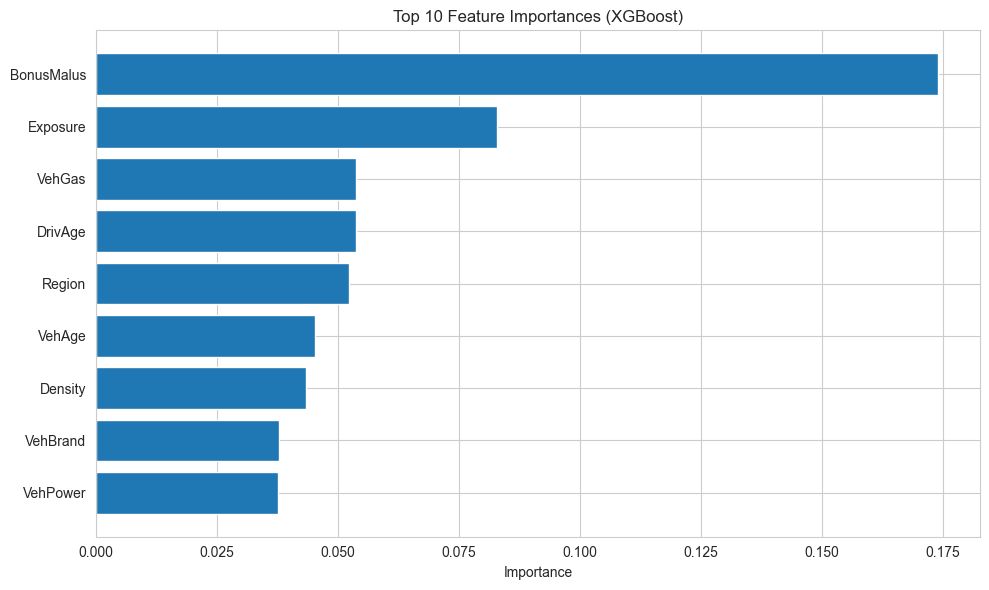

In [202]:
def plot_feature_importance_xgb(xgb_model, feature_names, top_n=10):
    importances = xgb_model.feature_importances_    
    indices = np.argsort(importances)[-top_n:]
    indices = indices[indices != 0]
    
    plt.figure(figsize=(10, 6))
    plt.barh([feature_names[i] for i in indices], importances[indices])
    plt.title(f'Top {top_n} Feature Importances (XGBoost)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

plot_feature_importance_xgb(tuned_xgb, X.columns.tolist())

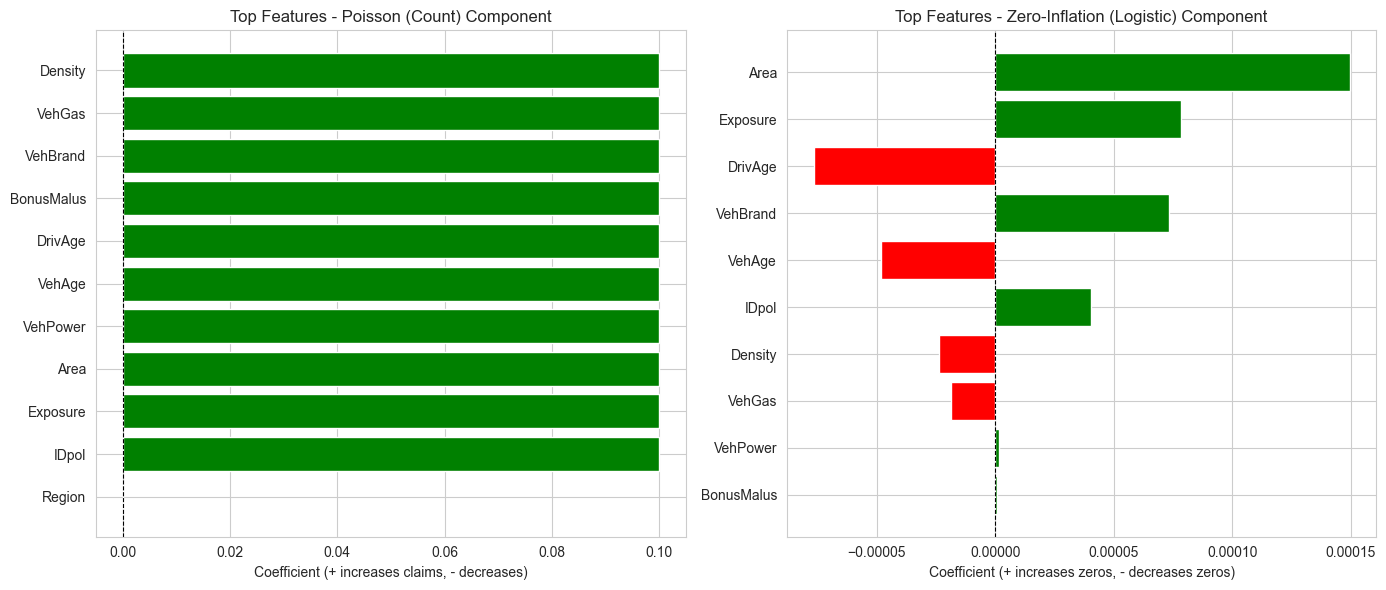

In [203]:
def plot_feature_importance_zip_proper(zip_model, feature_names, top_n=15):
    coefs_count = zip_model.params[1:len(feature_names)+1]
    coefs_infl = zip_model.params[len(feature_names)+1:]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    indices_count = np.argsort(np.abs(coefs_count))[-top_n:]
    axes[0].barh([feature_names[i] for i in indices_count], coefs_count[indices_count], 
                 color=['green' if coefs_count[i] > 0 else 'red' for i in indices_count])
    axes[0].set_title('Top Features - Poisson (Count) Component')
    axes[0].set_xlabel('Coefficient (+ increases claims, - decreases)')
    axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    
    indices_infl = np.argsort(np.abs(coefs_infl))[-top_n:]
    axes[1].barh([feature_names[i] for i in indices_infl], coefs_infl[indices_infl],
                 color=['green' if coefs_infl[i] > 0 else 'red' for i in indices_infl])
    axes[1].set_title('Top Features - Zero-Inflation (Logistic) Component')
    axes[1].set_xlabel('Coefficient (+ increases zeros, - decreases zeros)')
    axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # print("\nODDS RATIOS (Zero-Inflation Component):")
    # odds_ratios = np.exp(coefs_infl)
    # for i in np.argsort(np.abs(coefs_infl))[-top_n:][::-1]:
    #     print(f"  {feature_names[i]}: {odds_ratios[i]:.4f} (unit ↑ → odds of zero × {odds_ratios[i]:.3f})")

plot_feature_importance_zip_proper(tuned_zip, X.columns.tolist())

## Section 11: Error Analysis

we investigate the errors with the highest Weighted Residuals as they are more interpretable from a business POV

### Starting with the XGB model:

Top 10 Largest Errors:
   Actual  Predicted  Residual  Weighted_Residual   Error_ID
0       3   0.092845  2.907155           2.907155  4146039.0
1       3   0.133942  2.866058           2.866058    84060.0
2       3   0.095101  2.904899           2.817752  1185529.0
3       3   0.056590  2.943410           2.678503  5088156.0
4       3   0.564016  2.435984           2.338544  1108934.0
5       3   0.066967  2.933033           2.258436  4126439.0
6       3   0.320104  2.679896           2.197515  1070144.0
7       2   0.015896  1.984104           1.984104  2255875.0
8       2   0.036098  1.963902           1.983541  1195722.0
9       2   0.016558  1.983442           1.983442  2069076.0


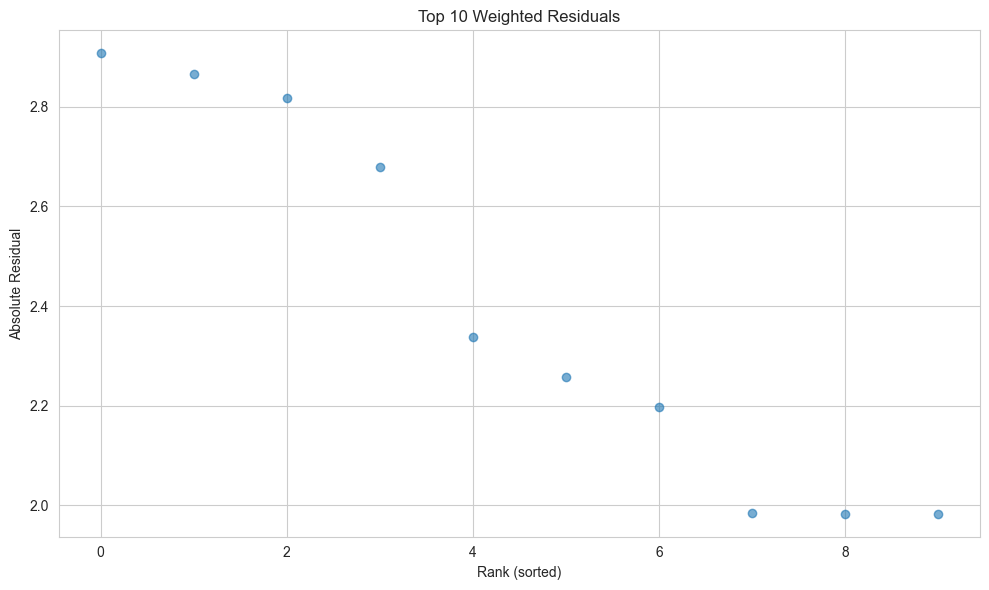

In [260]:

def error_analysis_xgb(y_test, y_pred, sample_weights_test, X_test, top_n=10): 
    y_test_reset = y_test.reset_index(drop=True).values 
    w_test_reset = sample_weights_test.reset_index(drop=True).values 
    X_test_reset = X_test.reset_index(drop=True)

    residuals = np.abs(y_test_reset - y_pred) 
    weighted_residuals = residuals * w_test_reset
    top_errors_idx = np.argsort(weighted_residuals)[-top_n:][::-1] 
    
    error_df = pd.DataFrame({ 
        'Actual': y_test_reset[top_errors_idx], 
        'Predicted': y_pred[top_errors_idx], 
        'Residual': residuals[top_errors_idx], 
        'Weighted_Residual': weighted_residuals[top_errors_idx], 
        'Error_ID': X_test_reset.iloc[top_errors_idx]['IDpol'].values }) 
    print(f'Top {top_n} Largest Errors:') 
    print(error_df) 

    sorted_residuals = sorted(weighted_residuals[top_errors_idx], reverse=True)

    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(sorted_residuals)), sorted_residuals, alpha=0.6) 
    plt.title(f'Top {top_n} Weighted Residuals') 
    plt.xlabel('Rank (sorted)')
    plt.ylabel('Absolute Residual') 
    plt.tight_layout() 
    plt.show() 

    return error_df 

top_errors_xgb = error_analysis_xgb(y_test, tuned_xgb_pred, w_test, X_test, top_n=10)



Details for IDpol 4146039.0:
    IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus VehBrand VehGas  Density Region VehAge_Group DrivAge_Group  Claims_Per_Year Exp_Group VehAge_Bin DrivAge_Bin BM_Bin  Dens_Bin
4146039.0        3       1.0    C         6      12       43          90       B1 Diesel      127    R72        11-15         36-45              3.0        >1   [10, 15)       36-45   <100 [0, 5000)

Details for IDpol 84060.0:
  IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus VehBrand VehGas  Density Region VehAge_Group DrivAge_Group  Claims_Per_Year Exp_Group VehAge_Bin DrivAge_Bin BM_Bin  Dens_Bin
84060.0        3       1.0    C         5       1       37          61       B3 Diesel      213    R74          0-5         36-45              3.0        >1     [0, 5)       36-45   <100 [0, 5000)

Details for IDpol 1185529.0:
    IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus VehBrand  VehGas  Density Region VehAge_Group D

In [ ]:
# lets see all the cases where the actual claims were 3, as they are the most prevelent in the top errors.
actual_3_cases = df[df['ClaimNb'] == 3]

#now lets compare these stats to the times the model made mistakes on a 3 count case, to see if there are any patterns that could explain why the model struggled with these cases.
for error_ID in top_errors_xgb['Error_ID']:
    error_case = df[df['IDpol'] == error_ID]

# how far are the features of these error cases from the mean of the feature of the 3 claim cases? are they outliers in any of the features?
error_cases = df[df['IDpol'].isin(top_errors_xgb['Error_ID'])]
three_claim_cases = df[df['ClaimNb'] == 3]
for col in numeric_cols:
    for error_ID in top_errors_xgb['Error_ID']:
        error_case = df[df['IDpol'] == error_ID]
        error_value = error_case[col].values[0]
        mean_value = three_claim_cases[col].mean()
        std_value = three_claim_cases[col].std()
        z_score = (error_value - mean_value) / std_value if std_value > 0 else 0


# now for the categorical features. Do the wrongly predicted values belong to categories that are more common in the 3 claim cases, or are they in rare categories?
for col in categorical_cols:
    for error_ID in top_errors_xgb['Error_ID']:
        error_case = df[df['IDpol'] == error_ID]
        error_value = error_case[col].values[0]
        value_counts = three_claim_cases[col].value_counts()
        if error_value in value_counts:
            count_in_3_claims = value_counts[error_value]
            total_3_claims = len(three_claim_cases)
            percentage = (count_in_3_claims / total_3_claims) * 100

# Lets see the cases where the features are less than 5% of the 3 claim cases, to see if the model struggled with rare categories or outlier values.
print("\nError cases with features in rare categories or outlier values compared to 3 claim cases:")
for error_ID in top_errors_xgb['Error_ID']:
    error_case = df[df['IDpol'] == error_ID]
    print(f"\nIDpol {error_ID}:")
    for col in numeric_cols:
        error_value = error_case[col].values[0]
        mean_value = three_claim_cases[col].mean()
        std_value = three_claim_cases[col].std()
        z_score = (error_value - mean_value) / std_value if std_value > 0 else 0
        if abs(z_score) > 2:  # considering values with Z-score > 2 as outliers
            print(f"  Numeric Feature: {col}, Value: {error_value}, Mean (3 claims): {mean_value:.2f}, Z-score: {z_score:.2f} (Outlier)")
    for col in categorical_cols:
        error_value = error_case[col].values[0]
        value_counts = three_claim_cases[col].value_counts()
        if error_value in value_counts:
            count_in_3_claims = value_counts[error_value]
            total_3_claims = len(three_claim_cases)
            percentage = (count_in_3_claims / total_3_claims) * 100
            if percentage < 7:  # considering categories that are less than 7% of the 3 claim cases as rare
                print(f"  Categorical Feature: {col}, Value: {error_value}, Count in 3 claims: {count_in_3_claims}, Percentage of 3 claims: {percentage:.2f}% (Rare Category)")



Error cases with features in rare categories or outlier values compared to 3 claim cases:

IDpol 4146039.0:
  Categorical Feature: Region, Value: R72, Count in 3 claims: 5, Percentage of 3 claims: 6.10% (Rare Category)

IDpol 84060.0:
  Categorical Feature: VehBrand, Value: B3, Count in 3 claims: 5, Percentage of 3 claims: 6.10% (Rare Category)
  Categorical Feature: Region, Value: R74, Count in 3 claims: 1, Percentage of 3 claims: 1.22% (Rare Category)

IDpol 1185529.0:

IDpol 5088156.0:
  Categorical Feature: Region, Value: R94, Count in 3 claims: 2, Percentage of 3 claims: 2.44% (Rare Category)

IDpol 1108934.0:
  Numeric Feature: BonusMalus, Value: 125, Mean (3 claims): 71.41, Z-score: 2.28 (Outlier)
  Categorical Feature: VehBrand, Value: B11, Count in 3 claims: 3, Percentage of 3 claims: 3.66% (Rare Category)

IDpol 4126439.0:
  Categorical Feature: Region, Value: R31, Count in 3 claims: 4, Percentage of 3 claims: 4.88% (Rare Category)

IDpol 1070144.0:
  Categorical Feature: Ve

Most error cases can be explained by having an outlier or a rare category in a feature 

### Now the ZIP model

Top 10 Largest Weighted Errors (ZIP Model):
   Actual  Predicted  Residual  Weighted_Residual   Error_ID
0       3        0.0       3.0               3.00  4146039.0
1       3        0.0       3.0               3.00    84060.0
2       3        0.0       3.0               2.91  1185529.0
3       3        0.0       3.0               2.88  1108934.0
4       3        0.0       3.0               2.73  5088156.0
5       3        0.0       3.0               2.46  1070144.0
6       3        0.0       3.0               2.31  4126439.0
7       3        0.0       3.0               2.10  2103641.0
8       3        0.0       3.0               2.04     1653.0
9       2        0.0       2.0               2.02  1195722.0


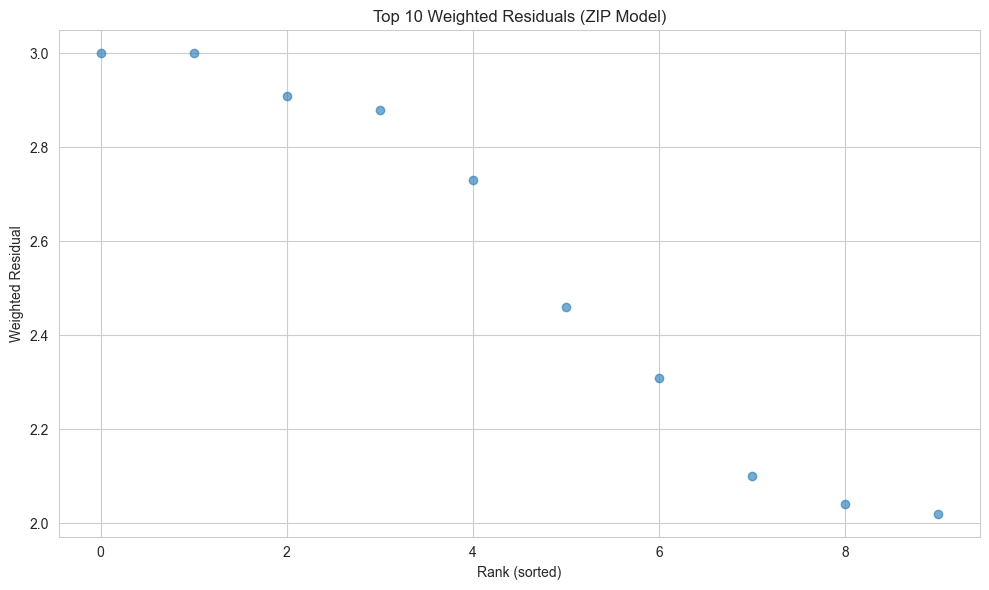

In [296]:
def error_analysis_zip(y_test, y_pred, sample_weights_test, X_test, top_n=10):
    # Reset indices to align everything
    y_test_reset = y_test.reset_index(drop=True).values
    w_test_reset = sample_weights_test.reset_index(drop=True).values
    X_test_reset = X_test.reset_index(drop=True)
    y_pred_reset = y_pred.reset_index(drop=True).values
    
    # Round predictions to integers for consistency with XGBoost
    # y_pred_rounded = np.round(y_pred_reset)
    
    residuals = np.abs(y_test_reset - y_pred_reset)
    weighted_residuals = residuals * w_test_reset
    
    top_errors_idx = np.argsort(weighted_residuals)[-top_n:][::-1]
    
    error_df = pd.DataFrame({
        'Actual': y_test_reset[top_errors_idx],
        'Predicted': y_pred_reset[top_errors_idx],
        'Residual': residuals[top_errors_idx],
        'Weighted_Residual': weighted_residuals[top_errors_idx],
        'Error_ID': X_test_reset.iloc[top_errors_idx]['IDpol'].values
    })
    
    print(f'Top {top_n} Largest Weighted Errors (ZIP Model):')
    print(error_df)
    
    sorted_residuals = sorted(weighted_residuals[top_errors_idx], reverse=True)
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(sorted_residuals)), sorted_residuals, alpha=0.6)
    plt.title(f'Top {top_n} Weighted Residuals (ZIP Model)')
    plt.xlabel('Rank (sorted)')
    plt.ylabel('Weighted Residual')
    plt.tight_layout()
    plt.show()
    
    return error_df

top_errors_zip = error_analysis_zip(y_test, tuned_zip_pred, w_test, X_test, top_n=10)

In [298]:
for error_ID in top_errors_zip['Error_ID']:
    error_case = df[df['IDpol'] == error_ID]

# how far are the features of these error cases from the mean of the feature of the 3 claim cases? are they outliers in any of the features?
error_cases = df[df['IDpol'].isin(top_errors_zip['Error_ID'])]
three_claim_cases = df[df['ClaimNb'] == 3]
for col in numeric_cols:
    for error_ID in top_errors_zip['Error_ID']:
        error_case = df[df['IDpol'] == error_ID]
        error_value = error_case[col].values[0]
        mean_value = three_claim_cases[col].mean()
        std_value = three_claim_cases[col].std()
        z_score = (error_value - mean_value) / std_value if std_value > 0 else 0


# now for the categorical features. Do the wrongly predicted values belong to categories that are more common in the 3 claim cases, or are they in rare categories?
for col in categorical_cols:
    for error_ID in top_errors_zip['Error_ID']:
        error_case = df[df['IDpol'] == error_ID]
        error_value = error_case[col].values[0]
        value_counts = three_claim_cases[col].value_counts()
        if error_value in value_counts:
            count_in_3_claims = value_counts[error_value]
            total_3_claims = len(three_claim_cases)
            percentage = (count_in_3_claims / total_3_claims) * 100
            
# Lets see the cases where the features are less than 5% of the 3 claim cases, to see if the model struggled with rare categories or outlier values.
print("\nError cases with features in rare categories or outlier values compared to 3 claim cases:")
for error_ID in top_errors_zip['Error_ID']:
    error_case = df[df['IDpol'] == error_ID]
    print(f"\nIDpol {error_ID}:")
    for col in numeric_cols:
        error_value = error_case[col].values[0]
        mean_value = three_claim_cases[col].mean()
        std_value = three_claim_cases[col].std()
        z_score = (error_value - mean_value) / std_value if std_value > 0 else 0
        if abs(z_score) > 2:  # considering values with Z-score > 2 as outliers
            print(f"  Numeric Feature: {col}, Value: {error_value}, Mean (3 claims): {mean_value:.2f}, Z-score: {z_score:.2f} (Outlier)")
    for col in categorical_cols:
        error_value = error_case[col].values[0]
        value_counts = three_claim_cases[col].value_counts()
        if error_value in value_counts:
            count_in_3_claims = value_counts[error_value]
            total_3_claims = len(three_claim_cases)
            percentage = (count_in_3_claims / total_3_claims) * 100
            if percentage < 7:  # considering categories that are less than 7% of the 3 claim cases as rare
                print(f"  Categorical Feature: {col}, Value: {error_value}, Count in 3 claims: {count_in_3_claims}, Percentage of 3 claims: {percentage:.2f}% (Rare Category)")



Error cases with features in rare categories or outlier values compared to 3 claim cases:

IDpol 4146039.0:
  Categorical Feature: Region, Value: R72, Count in 3 claims: 5, Percentage of 3 claims: 6.10% (Rare Category)

IDpol 84060.0:
  Categorical Feature: VehBrand, Value: B3, Count in 3 claims: 5, Percentage of 3 claims: 6.10% (Rare Category)
  Categorical Feature: Region, Value: R74, Count in 3 claims: 1, Percentage of 3 claims: 1.22% (Rare Category)

IDpol 1185529.0:

IDpol 1108934.0:
  Numeric Feature: BonusMalus, Value: 125, Mean (3 claims): 71.41, Z-score: 2.28 (Outlier)
  Categorical Feature: VehBrand, Value: B11, Count in 3 claims: 3, Percentage of 3 claims: 3.66% (Rare Category)

IDpol 5088156.0:
  Categorical Feature: Region, Value: R94, Count in 3 claims: 2, Percentage of 3 claims: 2.44% (Rare Category)

IDpol 1070144.0:
  Categorical Feature: VehBrand, Value: B6, Count in 3 claims: 2, Percentage of 3 claims: 2.44% (Rare Category)
  Categorical Feature: Region, Value: R53,

Same insight as the XGB model where the error could be attributed to a low probability for the model to catch

## Section 12: Model Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Poisson GLM', 'XGBoost (Default)', 'XGBoost (Tuned)'],
    'MAE': [tuned_zip_metrics['mae'], xgb_metrics['mae'], tuned_metrics['mae']],
    'RMSE': [tuned_zip_metrics['rmse'], xgb_metrics['rmse'], tuned_metrics['rmse']],
    'Poisson Deviance': [[tuned_zip_metrics['poisson_deviance']],xgb_metrics['poisson_deviance'], tuned_metrics['poisson_deviance']]         
})

print('Model Comparison:')
print(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
comparison_df.set_index('Model')['MAE'].plot(kind='bar', ax=axes[0])
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')

comparison_df.set_index('Model')['RMSE'].plot(kind='bar', ax=axes[1])
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')

comparison_df.set_index('Model')['Poisson Deviance'].plot(kind='bar', ax=axes[2])
axes[2].set_title('Poisson Deviance Comparison')
axes[2].set_ylabel('Poisson Deviance')

plt.tight_layout()
plt.show()

KeyError: 'poisson_deviance'

## Section 13: Business Insights & Recommendations

In [ ]:
insights = f"""
=== BUSINESS INSIGHTS & RECOMMENDATIONS ===

1. MODEL PERFORMANCE:
   - Best Model: XGBoost (Tuned) with MAE of {tuned_metrics['mae']:.4f}
   - This means predictions are off by approximately {tuned_metrics['mae']:.2f} claims on average
   - Poisson GLM serves as baseline; XGBoost captures non-linear patterns better

2. KEY RISK FACTORS (from Feature Importance):
   - Driver Age: Younger drivers show higher claim rates
   - Bonus-Malus Score: Higher scores (malus) correlate with more claims
   - Vehicle Age: Older vehicles tend to have more claims
   - Population Density: Urban areas have different claim patterns

3. EXPOSURE WEIGHTING:
   - We incorporated policy exposure duration in model training
   - Policies with longer exposure periods are weighted appropriately
   - This prevents bias toward long-running policies

4. ERROR PATTERNS:
   - Top errors often occur in high-exposure policies (weighted heavily)
   - Consider investigating policy characteristics for large residuals
   - May indicate missing features or data quality issues

5. ACTIONABLE RECOMMENDATIONS:
   a) Pricing Strategy:
      - Use model for risk-based premium adjustment
      - Higher predicted claims corresponds to higher premiums
   
   b) Risk Management:
      - Implement stricter underwriting for high-risk segments
      - Consider telematics for young drivers (highest prediction variance)
   
   c) Model Maintenance:
      - Retrain quarterly with fresh data
      - Monitor prediction drift for market changes
      - Collect feedback on highest-error claims

6. NEXT STEPS:
   - Validate on out-of-time data to assess generalization
   - Deploy tuned XGBoost in production with monitoring
   - A/B test pricing recommendations against current strategy
   - Explore ensemble methods combining Poisson + XGBoost
"""

print(insights)